# Exploration vs Exploitation

## Setup

In [14]:
%load_ext autoreload
%autoreload 2

import time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import mediapy
import cv2

torch.manual_seed(0)
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
pd.set_option('display.width', 200)
print('device:', DEVICE)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
device: cuda:0


In [15]:
# --- model: one call replaces the hydra-compose + load_{denoiser,tokenizer} boilerplate ------
from dreamerv4uwm.planning.experiments.study.model import load_world_model, make_decode_fn, model_dims

# DYN_CKPT = '/home/mim-server/projects/rooholla/dreamerV4-UWM/checkpoints/blockcausal/pushT-post-train/97500.pt'
DYN_CKPT = '/home/mim-server/projects/felix/checkpoints/wamcl-pushT-15k.pt'
TOK_CKPT = '/home/mim-server/projects/rooholla/dreamerV4-UWM/checkpoints/tokenizer/pushT.pt'

denoiser, tokenizer, cfg = load_world_model(
    dynamics_ckpt=DYN_CKPT, tokenizer_ckpt=TOK_CKPT,
    config_name='dynamics/pushT-large',
    overrides=['denoiser.horizon_aware=false'],   # the config dir is anchored to the package
    device=DEVICE)

decode = make_decode_fn(tokenizer, DEVICE)        # (B,T,N,D) -> (B,T,3,H,W) in [0,1], bf16
DIMS = model_dims(denoiser)
print(DIMS)

/home/mim-server/miniconda3/envs/dreamerv4uwm/lib/python3.11/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'dynamics/pushT-large': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)


{'num_noise_levels': 128, 'num_latent_tokens': 256, 'latent_dim': 32, 'n_actions': 2}


In [16]:
# --- data: real PushT windows, same split/seed as the sweep ---------------------------------
from dreamerv4uwm.planning.experiments.study.data import make_dataset, encode_window

DATA_DIR = '/home/mim-server/datasets/pushT/h5/play'
dataset = make_dataset(DATA_DIR, window_size=64)          # split='train', split_seed=123, no shuffle
print('dataset windows:', len(dataset))

WINDOW_IDX = 1111                                          # a dataset INDEX (not a seed)
latents, actions = encode_window(dataset, tokenizer, WINDOW_IDX, DEVICE, DIMS['n_actions'])
print('latents', tuple(latents.shape), '| actions', tuple(actions.shape))

Train split: 64694 windows from 11 episodes
dataset windows: 64694
latents (1, 64, 256, 32) | actions (1, 64, 2)


In [17]:
# --- the only genuinely notebook-local code: display helpers --------------------------------
# Everything here is *display*; the science lives in the modules. All of them take LATENTS,
# since that is the currency the planner works in.

def to_rgb(lat):
    """(M,N,D) latents -> (M,H,W,3) uint8, in one batched decode."""
    v = decode(lat[:, None])[:, 0]
    return (v.permute(0, 2, 3, 1).clamp(0, 1) * 255).to(torch.uint8).cpu().numpy()


def show_state(lat, *, ax=None, annotate=True, title=None, figsize=(3.4, 3.4)):
    """Visualise ONE decoded latent state -- `lat` of shape (N,D) or (1,1,N,D).

    With `annotate=True` the frame carries the **reward's own overlay** (segmented T contour,
    centroid, target cross, score) via `reward.score_latent` + `annotate_t`: you see what the
    reward sees, not just the picture. Degrades gracefully for rewards without a segmentation
    (e.g. DINOGoalReward) -- you get the frame and the score, no contour.
    Returns the score.
    """
    score, dbg, rgb = reward.score_latent(lat)
    img = annotate_t(rgb, dbg) if annotate else rgb
    own = ax is None
    if own:
        _, ax = plt.subplots(figsize=figsize)
    ax.imshow(img); ax.axis('off')
    ax.set_title(f'r = {score:.3f}' if title is None else title, fontsize=9)
    if own:
        plt.tight_layout(); plt.show()
    return score


def show_states(lats, *, titles=None, ncols=8, annotate=False, title=None, cell=2.1):
    """Grid of decoded latent states -- `lats` of shape (M,N,D).

    `annotate=False` (default) is one batched decode for the whole grid; `annotate=True`
    overlays the reward on each panel and costs one decode per state.
    """
    M = int(lats.shape[0])
    ncol = max(1, min(M, ncols))
    nrow = -(-M // ncol)
    fig, axes = plt.subplots(nrow, ncol, figsize=(cell * ncol, cell * 1.18 * nrow), squeeze=False)
    rgb = None if annotate else to_rgb(lats)
    for k in range(nrow * ncol):
        ax = axes[k // ncol][k % ncol]
        ax.axis('off')
        if k >= M:
            continue
        lab = titles[k] if titles is not None else f'#{k}'
        if annotate:
            show_state(lats[k], ax=ax, annotate=True, title=lab)
        else:
            ax.imshow(rgb[k]); ax.set_title(lab, fontsize=8)
    if title:
        fig.suptitle(title, fontsize=11)
    plt.tight_layout(); plt.show()


def filmstrip(lat_seq, n=8, scores=None, title=None, row_h=2.4):
    """(T,N,D) -> a row of n evenly-spaced decoded frames, optionally captioned with rewards."""
    T = lat_seq.shape[0]
    idx = np.linspace(0, T - 1, min(n, T), dtype=int)
    rgb = to_rgb(lat_seq[idx])
    fig, axes = plt.subplots(1, len(idx), figsize=(1.9 * len(idx), row_h))
    for k, ax in enumerate(np.atleast_1d(axes)):
        ax.imshow(rgb[k]); ax.axis('off')
        lab = f't={idx[k]}' + (f'\nr={scores[idx[k]]:.2f}' if scores is not None else '')
        ax.set_title(lab, fontsize=8)
    if title:
        fig.suptitle(title, fontsize=11)
    plt.tight_layout(); plt.show()


def plotVideo(video, fps=10, label=True):
    """Play a (T,C,H,W) float[0,1] clip inline, with the frame index burnt in."""
    arr = (video.detach().cpu().permute(0, 2, 3, 1).to(torch.float32).numpy() * 255)
    arr = np.ascontiguousarray(arr.clip(0, 255).astype(np.uint8))
    if label:
        for i in range(arr.shape[0]):
            cv2.putText(arr[i], f'{i}', (8, 24), cv2.FONT_HERSHEY_SIMPLEX,
                        0.6, (255, 255, 255), 2, cv2.LINE_AA)
    mediapy.show_video(arr, fps=fps)


def plotLatentVideo(lat_seq, fps=10, **kw):
    """Same as plotVideo, straight from latents (T,N,D) -- one batched decode."""
    plotVideo(decode(lat_seq[None])[0], fps=fps, **kw)

In [18]:
# the real demo window this notebook plans from
plotLatentVideo(latents[0], fps=10)

This browser does not support the video tag.


ctx_z (1, 1, 256, 32) | ctx_a (1, 1, 2)


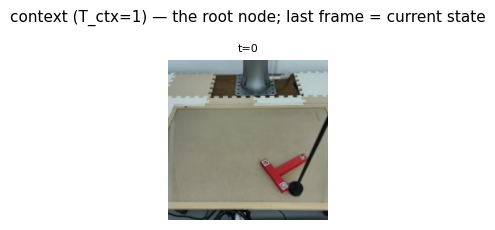

In [19]:
# --- a decision point: the context window a tree root holds ---------------------------------
T_CTX = 1

def make_state(t0, Tc=T_CTX):
    """(ctx_z, ctx_a) for the decision taken at frame t0+Tc of the window."""
    return latents[:, t0:t0 + Tc].clone(), actions[:, t0:t0 + Tc].clone()

cz, ca = make_state(24)
print('ctx_z', tuple(cz.shape), '| ctx_a', tuple(ca.shape))
filmstrip(cz[0], n=T_CTX, title=f'context (T_ctx={T_CTX}) — the root node; last frame = current state')

## Reward and descriptor

Two *different* objects that must agree on their segmentation settings:

* the **reward** scores a state (what the planner maximises),
* the **descriptor** `phi(state)` is the low-dimensional space diversity is measured in.

Raw latent distance is meaningless here (8192-D, distances concentrate), which is why the
diversity metrics work on the decoded T-pose instead. Swap the pair together: `TCenterReward`
goes with `TPoseDescriptor` (orientation as an axis), `TCenterAngleReward` with
`THeadingDescriptor` (upright vs upside-down distinguished).

descriptor dim = 5


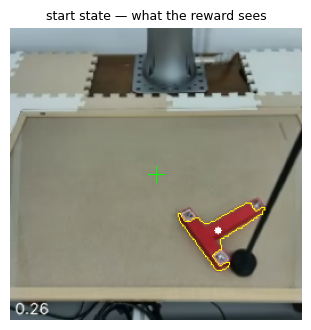

start reward = 0.258


In [ ]:
from dreamerv4uwm.planning import TCenterReward, TCenterAngleReward, annotate_t
from dreamerv4uwm.planning.experiments.study.descriptors import TPoseDescriptor, THeadingDescriptor

SEG_KW = dict(center_xy=(0.5, 0.5), sigma=0.25, target_heading_deg=90.0)     # shared by reward AND descriptor

# reward     = TCenterReward(decode_fn=decode, **SEG_KW)
# descriptor = TPoseDescriptor(decode_fn=decode, dup_eps=0.05, **SEG_KW)

# upright-aware alternative (use the two together):
reward     = TCenterAngleReward(decode_fn=decode, combine='weighted_sum', **SEG_KW)
descriptor = THeadingDescriptor(decode_fn=decode, dup_eps=0.06, orient_weight=0.5, **SEG_KW)

print(f'descriptor dim = {descriptor.dim}')
s0 = show_state(cz[0, -1], title='start state — what the reward sees')
print(f'start reward = {s0:.3f}')

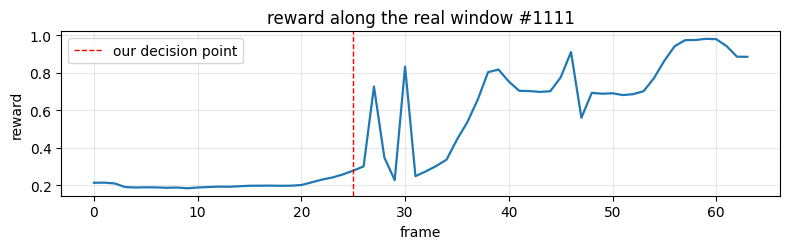

In [21]:
# sanity: the reward should vary smoothly along the REAL demo (no reward -> no planning)
r_real = reward(latents[0]).cpu().numpy()
plt.figure(figsize=(8, 2.6))
plt.plot(r_real, lw=1.6); plt.axvline(24 + T_CTX, color='r', ls='--', lw=1, label='our decision point')
plt.xlabel('frame'); plt.ylabel('reward'); plt.grid(alpha=.3); plt.legend()
plt.title(f'reward along the real window #{WINDOW_IDX}'); plt.tight_layout(); plt.show()

# Plans

In [22]:
from dreamerv4uwm.planning import MCTS, PlanConfig
from dreamerv4uwm.planning.experiments.study.baselines import compute_baselines
from dreamerv4uwm.planning.experiments.study.metrics import compute_tree_metrics
from dreamerv4uwm.planning.experiments.study.run_tree import run_one_tree, _plan_peak, _plan_last

SEG_KW = dict(center_xy=(0.5, 0.5), sigma=0.25, target_heading_deg=90.0)     # shared by reward AND descriptor
reward     = TCenterAngleReward(decode_fn=decode, combine='weighted_sum', **SEG_KW)
descriptor = THeadingDescriptor(decode_fn=decode, dup_eps=0.06, orient_weight=0.5, **SEG_KW)

plan_cfg = PlanConfig(horizon=16, branching=5, max_depth=5, sim_horizon=16, sim_rollouts=3,
                      n_iterations=36, c_ucb=0.5, gamma=0.98, n_min=0, K_steps=8,
                      ctx_noise=0.0, action_temp=1.0, max_ctx=3)

planner = MCTS(denoiser, reward, plan_cfg, seed=0, trace=True)   # trace=True -> time-resolved metrics
t = time.time(); out = planner.plan(cz, ca, verbose=True); secs = time.time() - t
print(f'\n{secs:.1f}s | nodes={len(planner.all_nodes)} | forwards={planner.n_forward} '
      f'| plan = {len(out["best_path"])} edges')

  iter   7/36  nodes=11  forwards=9
  iter  14/36  nodes=21  forwards=18
  iter  21/36  nodes=26  forwards=26
  iter  28/36  nodes=51  forwards=38
  iter  35/36  nodes=66  forwards=48

61.8s | nodes=71 | forwards=50 | plan = 4 edges


In [23]:
tree_peak, tree_last = _plan_peak(reward, out), _plan_last(reward, out)
bl = compute_baselines(denoiser, reward, cz, ca, plan_cfg,
                       tree_peak=tree_peak, tree_last=tree_last, n_random=12, seed=1)

print(f'start reward      {bl["root_reward"]:+.3f}')
print(f'plan   peak/last  {tree_peak:+.3f} / {tree_last:+.3f}')
print(f'random peak/last  {bl["random_peak"]:+.3f} / {bl["random_last"]:+.3f}   '
      f'-> g_random_peak {bl["g_random_peak"]:+.3f}  g_random_last {bl["g_random_last"]:+.3f}')
print(f'greedy peak/last  {bl["greedy_peak"]:+.3f} / {bl["greedy_last"]:+.3f}   '
      f'-> g_greedy_peak {bl["g_greedy_peak"]:+.3f}  g_greedy_last {bl["g_greedy_last"]:+.3f}')
print('\n(peak = best frame anywhere; last = where the trajectory ENDS. Compare like with like.)')

start reward      +0.284
plan   peak/last  +0.993 / +0.883
random peak/last  +0.889 / +0.491   -> g_random_peak +0.104  g_random_last +0.391
greedy peak/last  +0.984 / +0.887   -> g_greedy_peak +0.009  g_greedy_last -0.004

(peak = best frame anywhere; last = where the trajectory ENDS. Compare like with like.)


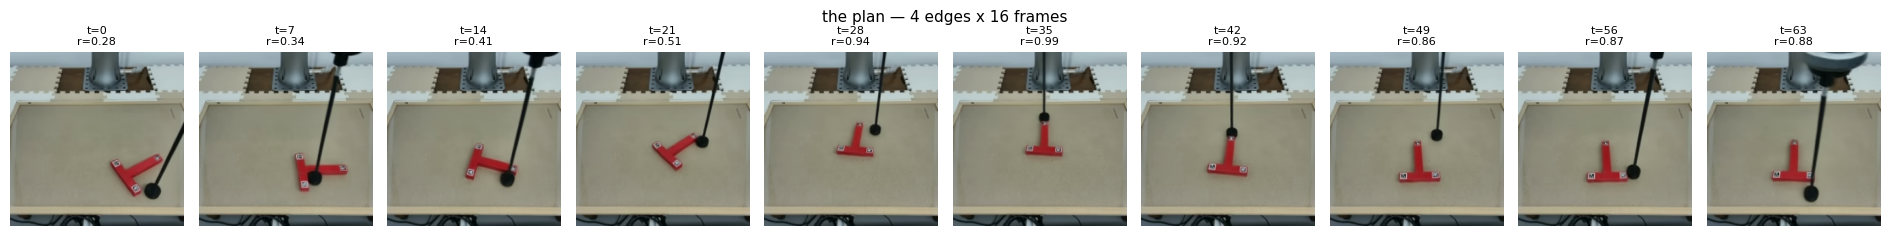

This browser does not support the video tag.


In [24]:
plan_z = out['plan_z']                                   # (n_edges, H, N, D)
flat = plan_z.reshape(-1, plan_z.shape[-2], plan_z.shape[-1])
filmstrip(flat, n=10, scores=reward(flat).cpu().numpy(),
          title=f'the plan — {plan_z.shape[0]} edges x {plan_z.shape[1]} frames')

plotLatentVideo(flat, fps=6)                     # the same plan, played

## Exploit vs Explore

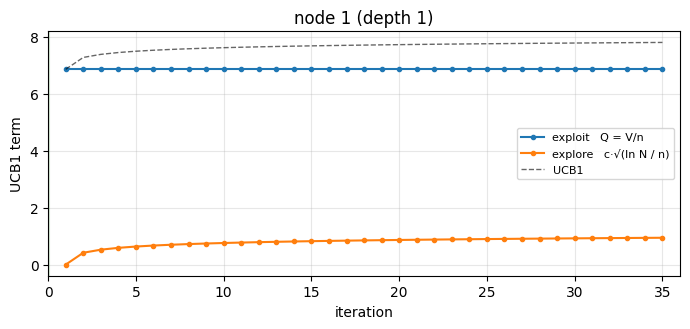

In [25]:
import numpy as np, matplotlib.pyplot as plt

node = planner.root.children[0]
s = planner.ucb_series(node)

it  = np.array(s['iter'], float)
ex  = np.array(s['exploit'], float)
xp  = np.array(s['explore'], float)
sel = np.array(s['selected'], bool)
m   = np.isfinite(xp) & np.isfinite(ex)          # drops the n_visit==0 row

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(it[m], ex[m], 'o-', ms=3, label='exploit   Q = V/n')
ax.plot(it[m], xp[m], 'o-', ms=3, label='explore   c·√(ln N / n)')
ax.plot(it[m], ex[m] + xp[m], 'k--', lw=1, alpha=.6, label='UCB1')
for i in it[sel]:                                 # iterations where this arm won
    ax.axvline(i, color='green', alpha=.15, lw=3)
ax.set_xlabel('iteration'); ax.set_ylabel('UCB1 term')
ax.set_xlim(0, planner.cfg.n_iterations)
ax.set_title(f'node {node.id} (depth {node.depth})')
ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()


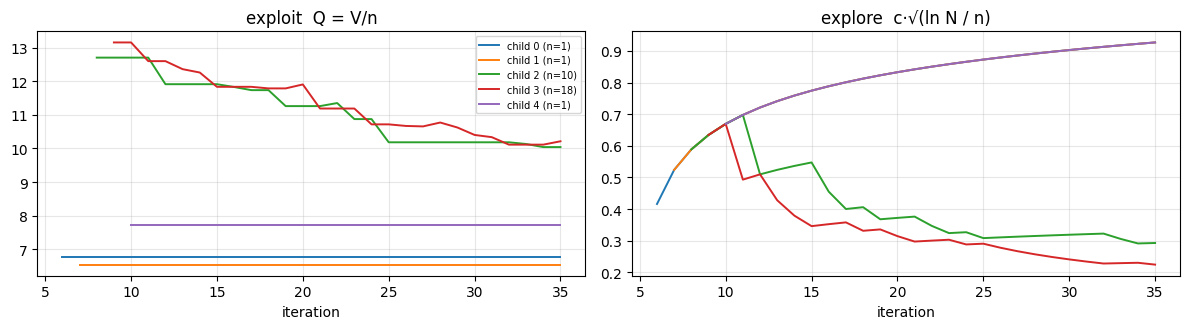

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4), sharex=True)
for k, ch in enumerate(planner.root.children[3].children):
    s = planner.ucb_series(ch)
    it = np.array(s['iter'], float)
    for a_, key in zip(ax, ('exploit', 'explore')):
        y = np.array(s[key], float); m = np.isfinite(y)
        a_.plot(it[m], y[m], '-', lw=1.4, label=f'child {k} (n={ch.n_visit})')
for a_, t in zip(ax, ('exploit  Q = V/n', 'explore  c·√(ln N / n)')):
    a_.set_title(t); a_.set_xlabel('iteration'); a_.grid(alpha=.3)
ax[0].legend(fontsize=7)
plt.tight_layout(); plt.show()